# USGS dataretrieval Python Package Statistics Examples

This notebook provides examples of using the Python dataretrieval package to retrieve summary statistics for observed variables at a United States Geological Survey (USGS) monitoring location using the **USGS Water Data API** via the `waterdata` module. The `waterdata` module is the recommended way to access USGS water data and replaces the deprecated `nwis` module.

Two statistics functions are demonstrated:

* `get_stats_date_range()` — monthly, calendar-year, and water-year summaries (the "observationIntervals" service).
* `get_stats_por()` — day-of-year and month-of-year summaries over the full period of record (the "observationNormals" service).

### Install the Package

Use the following code to install the package if it doesn't exist already within your Jupyter Python environment.

In [1]:
!pip install dataretrieval

Load the package so you can use it along with other packages used in this notebook.

In [2]:
from IPython.display import display
from matplotlib import ticker

from dataretrieval import waterdata


### Basic Usage

This example uses `get_stats_date_range()` to retrieve monthly and annual statistics for an observed variable at a USGS monitoring location. Commonly used arguments include:

* **monitoring_location_id** (string or list of strings): USGS monitoring location id(s), formed as the agency code and site number joined by a hyphen (e.g. `"USGS-02319394"`).
* **parameter_code** (string or list of strings): 5-digit USGS parameter code(s), e.g. `"00060"` (discharge).
* **computation_type** (string or list of strings): the statistic(s) to compute — one or more of `arithmetic_mean`, `maximum`, `median`, `minimum`, `percentile`.
* **start_date** / **end_date** (string): optionally bound the period summarized, in `YYYY-MM-DD` format.

#### Example 1: Get monthly and annual mean discharge for a single monitoring location

In [3]:
# Set the parameters needed to retrieve data
site = "USGS-02319394"
parameter_code = "00060"  # Discharge

# Retrieve the statistics (monthly, calendar-year, and water-year means)
x1 = waterdata.get_stats_date_range(
    monitoring_location_id=site,
    parameter_code=parameter_code,
    computation_type="arithmetic_mean",
)
print("Retrieved " + str(len(x1[0])) + " statistic values.")

Retrieving: observationIntervals · 1 page · 344 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


Retrieved 344 statistic values.


### Interpreting the Result

Each `waterdata` function returns a tuple of a pandas data frame and a metadata object. The data frame holds the computed statistics; each row is one interval, identified by the `interval_type` column (`month`, `calendar_year`, or `water_year`), with the computed statistic in the `value` column.

Once you've got the data frame, there are several useful things you can do to explore the data.

In [4]:
# Display the data frame as a table
display(x1[0])

,geometry,monitoring_location_id,monitoring_location_name,site_type,site_type_code,country_code,state_code,county_code,start_date,end_date,interval_type,value,percentile,sample_count,approval_status,computation_id,computation,parameter_code,unit_of_measure,parent_time_series_id
0,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2000-11-01,2000-11-30,month,600.967,NaN,30,approved,30eb30d0-c252-4601-a702-1e053e387200,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
1,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2000-12-01,2000-12-31,month,812.903,NaN,31,approved,0bfbd34c-53ed-429b-bea1-facc88c3c639,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
2,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2001-01-01,2001-01-31,month,1668.387,NaN,31,approved,533f6064-f298-4eb1-b74f-da0c09d8c525,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
3,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2001-02-01,2001-02-28,month,1234.286,NaN,28,approved,67ee8c57-e9d0-42a9-826f-a86dbac7a377,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
4,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2001-03-01,2001-03-31,month,3782.581,NaN,31,approved,7d13bc10-dacc-48c5-bf41-63c13569f47c,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2021-10-01,2022-09-30,water_year,2034.863,NaN,365,approved,a579a7a4-b5bc-45ce-a754-9d784d05dffe,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
340,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2022-10-01,2023-09-30,water_year,1731.784,NaN,365,approved,ef755db3-4cb0-44ec-9192-1a2f85708608,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
341,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2023-10-01,2024-09-30,water_year,3392.778,NaN,365,approved,f73ed1da-35e0-4167-9387-cab6aad5961c,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840
342,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2024-10-01,2025-09-30,water_year,1938.863,NaN,365,approved,5004f92c-d1f8-4c1c-9a41-ce1e73d15888,arithmetic_mean,00060,ft^3/s,dabac917c8ea4f66a163ddc9d3bb4840


Show the data types of the columns in the resulting data frame.

In [5]:
print(x1[0].dtypes)

geometry                    geometry
monitoring_location_id           str
monitoring_location_name         str
site_type                        str
site_type_code                   str
country_code                     str
state_code                       str
county_code                      str
start_date                       str
end_date                         str
interval_type                    str
value                            str
percentile                   float64
sample_count                   int64
approval_status                  str
computation_id                   str
computation                      str
parameter_code                   str
unit_of_measure                  str
parent_time_series_id            str
dtype: object


Make a quick time series plot of the annual (calendar-year) mean values.

Text(0, 0.5, 'Annual mean discharge (cfs)')

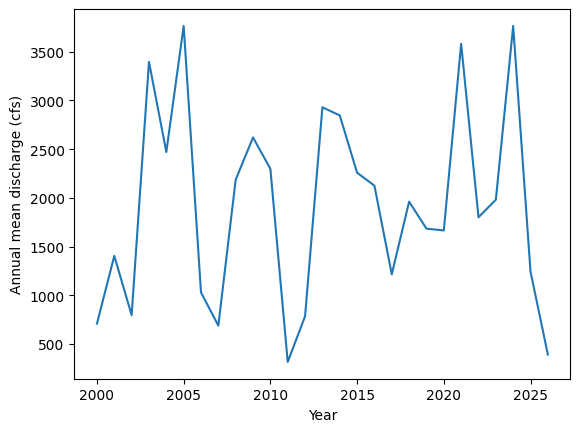

In [6]:
# select the annual (calendar-year) means into a plain DataFrame for plotting.
# The statistics services return a GeoDataFrame carrying a site-point geometry,
# and report numeric values as strings, so we coerce ``value`` to float.
annual = x1[0].loc[
    x1[0]["interval_type"] == "calendar_year", ["start_date", "value"]
].copy()
annual["year"] = annual["start_date"].str[:4].astype(int)
annual["value"] = annual["value"].astype(float)
annual = annual.sort_values("year")

ax = annual.plot(x="year", y="value", legend=False)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean discharge (cfs)")

The other part of the result is a metadata object describing the query that was executed. For example, you can access the URL that was assembled to retrieve the requested data from the USGS Water Data API.

In [7]:
print("The query URL used to retrieve the data was: " + x1[1].url)

The query URL used to retrieve the data was: https://api.waterdata.usgs.gov/statistics/v0/observationIntervals?computation_type=arithmetic_mean&monitoring_location_id=USGS-02319394&page_size=1000&parameter_code=00060


### Additional Examples

#### Example 2: Get monthly and annual mean statistics for two monitoring locations

Multiple monitoring locations and parameter codes can be requested at once; only the data that are available are returned.

In [8]:
x2 = waterdata.get_stats_date_range(
    monitoring_location_id=["USGS-02319394", "USGS-02171500"],
    parameter_code=["00010", "00060"],
    computation_type="arithmetic_mean",
)
display(x2[0])

Retrieving: observationIntervals · 1 page · 2,114 rows

,geometry,monitoring_location_id,monitoring_location_name,site_type,site_type_code,country_code,state_code,county_code,start_date,end_date,interval_type,value,percentile,sample_count,approval_status,computation_id,computation,parameter_code,unit_of_measure,parent_time_series_id
0,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,1942-05-01,1942-05-31,month,584.032,NaN,31,approved,043dcd51-8a2f-48ca-bb20-20933651f633,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
1,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,1942-06-01,1942-06-30,month,2571.333,NaN,30,approved,0a96c646-ca99-45de-b8ea-b85954d5e029,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
2,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,1942-07-01,1942-07-31,month,400.742,NaN,31,approved,88991dcf-0994-4d18-be50-378146f193fe,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
3,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,1942-08-01,1942-08-31,month,549.581,NaN,31,approved,64fd8688-07e2-4710-8cd4-57ee0e25ff66,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
4,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,1942-09-01,1942-09-30,month,1338.467,NaN,30,approved,c8b93535-460a-4dfd-91ab-a5ec4a16c827,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2109,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2021-10-01,2022-09-30,water_year,20.784,NaN,351,approved,6bdfe85c-4494-4143-84ce-e30849f1e68b,arithmetic_mean,00010,degC,ea8d8089780f48428cff4a5ba344f1aa
2110,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2022-10-01,2023-09-30,water_year,21.121,NaN,361,approved,c4ec6635-83cf-4d54-9fd8-caed23b96a98,arithmetic_mean,00010,degC,ea8d8089780f48428cff4a5ba344f1aa
2111,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2023-10-01,2024-09-30,water_year,20.383,NaN,342,approved,e533a96f-655a-4753-b960-0560b0be2d97,arithmetic_mean,00010,degC,ea8d8089780f48428cff4a5ba344f1aa
2112,POINT (-83.18014 30.41049),USGS-02319394,"WITHLACOOCHEE RIVER NR LEE, FLA",Stream,ST,US,12,079,2024-10-01,2025-09-30,water_year,20.928,NaN,348,approved,197d9815-4ecd-4b89-a01e-50e128e4dbd6,arithmetic_mean,00010,degC,ea8d8089780f48428cff4a5ba344f1aa


#### Example 3: Day-of-year mean and median statistics over the period of record

`get_stats_por()` summarizes the full period of record by day of year (and month of year). Here we request both the mean and median daily statistics for discharge at a monitoring location.

In [9]:
x3 = waterdata.get_stats_por(
    monitoring_location_id="USGS-02171500",
    parameter_code="00060",
    computation_type=["arithmetic_mean", "median"],
)
display(x3[0])

Retrieving: observationNormals · 1 page · 756 rows

,geometry,monitoring_location_id,monitoring_location_name,site_type,site_type_code,country_code,state_code,county_code,time_of_year,time_of_year_type,value,percentile,sample_count,approval_status,computation_id,computation,parameter_code,unit_of_measure,parent_time_series_id
0,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,01-01,day_of_year,2046.695,NaN,82,approved,e7827589-ff6e-472d-9864-1bfe558b9639,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
1,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,01-02,day_of_year,2041.866,NaN,82,approved,9e8feb48-3652-4bca-82dc-c2f2a65650e5,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
2,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,01-03,day_of_year,2080.963,NaN,82,approved,35c0af68-80d2-4635-865c-bb224bfb5e9a,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
3,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,01-04,day_of_year,2434.256,NaN,82,approved,eacd3baa-e0ab-4c08-8334-bb3ed3b916c8,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
4,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,01-05,day_of_year,2597.819,NaN,83,approved,19f28744-96cb-4cfa-9d28-5f114b82fcc6,arithmetic_mean,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,08,month_of_year,563.0,50.0,84,approved,b3fc0cec-1732-4bac-b153-a18bef567453,median,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
752,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,09,month_of_year,563.0,50.0,84,approved,8cd55012-5b16-42f7-8cb3-b234aa15f859,median,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
753,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,10,month_of_year,563.0,50.0,84,approved,a1b160db-bc3f-44e7-a150-881474373276,median,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
754,POINT (-80.14136 33.45378),USGS-02171500,"SANTEE RIVER NEAR PINEVILLE, SC",Stream,ST,US,45,015,11,month_of_year,561.5,50.0,84,approved,48757820-8d5e-4407-bced-bca2717c6c97,median,00060,ft^3/s,218ab832dc5a4c4b9fb1d51efa232d15
